# UL-UNAS Denoising & Silero VAD Pipeline

This notebook demonstrates an end-to-end audio processing and Voice Activity Detection (VAD) pipeline designed for lightweight deployment environments (such as Apache Beam / Google Cloud Dataflow).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/watch-duty/radio-transcription/blob/main/model/colabs/segmentation/silero_and_ul_unas_wet_dry_VAD_mixture.ipynb)

### Key Features:
* **Zero PyTorch Dependency**: To avoid massive dependency bloat in worker instances, this pipeline relies exclusively on **ONNX Runtime**, **NumPy**, and **Pedalboard**. Resampling heavily relies on a custom NumPy implementation of `torchaudio`'s sinc resampler to maintain the precise audio characteristics required by the denoiser.
* **UL-UNAS Denoiser**: Applies a state-of-the-art streaming denoiser to remove background noise.
* **Silero VAD**: Detects speech segments using ONNX-based Silero VAD, enhanced with custom hysteresis (distinct onset/offset thresholds) and padding logic to prevent fragmented segments.
* **Audio Mastering**: Incorporates dry/wet blending, bandpass filtering, and an EQ presence boost to optimize voice clarity before VAD processing.
* **Evaluation**: Includes built-in tools to visualize audio waveforms, VAD probabilities, and automatically evaluate VAD recall/precision against labeled ground-truth segments.

**Note**: Currently, this Colab has evaluation support configured *only* for the specific audio files listed as keys in the `GROUND_TRUTH_SEGMENTS` dictionary. These files are located in the `models/colabs/data/segmentation` directory.

In [74]:
!pip install -q onnxruntime pedalboard

In [75]:
# @title Constants
SILERO_MODEL_FILENAME = "silero_vad.onnx"
ULUNAS_MODEL_FILENAME = "ulunas_stream_simple.onnx"

In [76]:
# @title Download the Silero VAD model
!wget -q --show-progress -N https://github.com/snakers4/silero-vad/raw/refs/tags/v6.2.1/src/silero_vad/data/{SILERO_MODEL_FILENAME}

silero_vad.onnx     100%[===================>]   2.22M  --.-KB/s    in 0.06s   


In [77]:
# @title Download the UL-UNAS denoiser model
!wget -q --show-progress -N https://github.com/Xiaobin-Rong/ul-unas/raw/refs/heads/main/ulunas_onnx/onnx_models/{ULUNAS_MODEL_FILENAME}

ulunas_stream_simpl 100%[===================>] 770.48K  --.-KB/s    in 0.05s   


In [78]:
# @title Imports
import base64
import io
import math
import os
import pathlib
import subprocess
import tempfile
import wave

import numpy as np
import onnxruntime as ort
import soundfile as sf
from google.colab import files
from IPython.display import HTML, Audio, display
from numba import njit
from pedalboard import HighpassFilter, LowpassFilter, PeakFilter, Pedalboard

In [79]:
# @title Constants
GROUND_TRUTH_SEGMENTS = {
  "stess_test.flac": [
      (0.4, 2.85)
  ],
  "joined_sample.flac": [
    (8.3, 10.7),
    (12.3, 15.6),
    (20.3, 23.0),
    (26.2, 27.0)
  ],
  "bcfy_feeds_874e09a6-591d-40bc-91c2-a3e7cecaf5f0_token-5_20260409T215524Z_270.flac": [
    (0.0, 1.1),
    (1.95, 5.3),
    (7.25, 10.9),
    (11.6, 12.2)
  ],
  "audio_one_hour_pilot_audio_Amador_Cmd_20251209_10.wav": [
    (2.7, 12.5),
    (14.4, 15.8),
    (17.5, 24.6),
    (27.3, 29.7),
    (31.4, 33.7),
    (38.1, 40.5),
    (47.2, 49.4),
    (56.2, 60.6),
    (62.6, 65.3)
  ],
  "SKU_Disp_INPUT_20251208_11_original.wav": [
    (0.420, 2.593),
    (3.3, 5.788),
    (6.242,8.838),
    (8.861, 11.044),
    (11.691, 14.717),
    (14.811, 17.014),
    (17.781,19.707),
    (20.253,22.040),
    (22.843,24.669),
    (25.547,27.728),
    (28.471,29.830),
    (30.845,32.907),
    (33.003,34.615),
    (35.704,37.877),
    (40.570,41.772),
    (42.467,44.470),
    (45.874,49.212),
    (49.373,51.884),
    (52.768,54.178)
  ]
}

In [80]:
# @title Helper classes/functions

# Note: This Colab intentionally avoids using Pytorch to avoid the dependency
# bloat that would result in Dataflow worker instances. The performance
# of the UL-UNAS denoiser is highly dependent on the specific resampling
# implementation in torchaudio, so we provide an equivalent here in numpy.

def get_periodic_hann(window_length):
    return 0.5 * (1 - np.cos(2 * np.pi * np.arange(window_length) / window_length))

def custom_numpy_stft(wav, n_fft=512, hop_length=256):
    window = get_periodic_hann(n_fft)
    pad_len = n_fft // 2
    wav_padded = np.pad(wav, ((0, 0), (pad_len, pad_len)), mode="reflect")
    num_frames = 1 + (wav_padded.shape[1] - n_fft) // hop_length
    strides = (wav_padded.strides[0], wav_padded.strides[1] * hop_length, wav_padded.strides[1])
    frames = np.lib.stride_tricks.as_strided(wav_padded, shape=(wav.shape[0], num_frames, n_fft), strides=strides)
    windowed = frames * window
    spec = np.fft.rfft(windowed, n=n_fft, axis=-1)
    spec = np.transpose(spec, (0, 2, 1))
    return np.stack((np.real(spec), np.imag(spec)), axis=-1).astype(np.float32)

@njit(fastmath=True)
def _ola_step(frames, window, window_sq, out, window_sum, num_frames, hop_length, n_fft):
    batch_size = frames.shape[0]
    for b in range(batch_size):
        for i in range(num_frames):
            start = i * hop_length
            for j in range(n_fft):
                out[b, start + j] += frames[b, i, j] * window[j]
                window_sum[b, start + j] += window_sq[j]

def custom_numpy_istft(spec_stacked, length, n_fft=512, hop_length=256):
    window = get_periodic_hann(n_fft).astype(np.float32)
    spec_complex = spec_stacked[..., 0] + 1j * spec_stacked[..., 1]
    spec_complex = np.transpose(spec_complex, (0, 2, 1))
    frames = np.fft.irfft(spec_complex, n=n_fft, axis=-1).astype(np.float32)
    batch_size, num_frames, _ = frames.shape
    expected_len = (num_frames - 1) * hop_length + n_fft
    out = np.zeros((batch_size, expected_len), dtype=np.float32)
    window_sum = np.zeros((batch_size, expected_len), dtype=np.float32)
    window_sq = (window ** 2).astype(np.float32)

    _ola_step(frames, window, window_sq, out, window_sum, num_frames, hop_length, n_fft)

    window_sum[window_sum < 1e-10] = 1.0
    out = out / window_sum
    pad_len = n_fft // 2
    return out[:, pad_len : pad_len + length]

class TorchaudioHannResampler:
    def __init__(self, orig_freq: int, new_freq: int, lowpass_filter_width: int = 6, rolloff: float = 0.99):
        self.orig_freq = orig_freq
        self.new_freq = new_freq
        self.lowpass_filter_width = lowpass_filter_width
        self.gcd = math.gcd(orig_freq, new_freq)
        self.down = orig_freq // self.gcd
        self.up = new_freq // self.gcd
        self.kernel, self.width = self._get_sinc_resample_kernel(self.down, self.up, lowpass_filter_width, rolloff)

    def _get_sinc_resample_kernel(self, orig_freq, new_freq, lowpass_filter_width, rolloff):
        base_freq = min(orig_freq, new_freq) * rolloff
        width = math.ceil(lowpass_filter_width * orig_freq / base_freq)
        idx = np.arange(-width, width + orig_freq, dtype=np.float64)[None, None, :] / orig_freq
        t = np.arange(0, -new_freq, -1, dtype=np.float64)[:, None, None] / new_freq + idx
        t *= base_freq
        t = np.clip(t, -lowpass_filter_width, lowpass_filter_width)
        window = np.cos(t * math.pi / lowpass_filter_width / 2) ** 2
        t_pi = t * math.pi
        scale = base_freq / orig_freq
        kernels = np.zeros_like(t_pi)
        mask = (t_pi == 0)
        kernels[mask] = 1.0
        kernels[~mask] = np.sin(t_pi[~mask]) / t_pi[~mask]
        kernels *= window * scale
        return kernels.astype(np.float64), width

    def resample(self, waveform: np.ndarray) -> np.ndarray:
        is_1d = waveform.ndim == 1
        if is_1d: waveform = waveform[np.newaxis, :]
        orig_len = waveform.shape[-1]
        wav_padded = np.pad(waveform.astype(np.float64), ((0, 0), (self.width, self.width + self.down)), mode="constant")
        batch, length = wav_padded.shape
        kernel_size = self.kernel.shape[2]
        num_frames = (length - kernel_size) // self.down + 1
        strides = (wav_padded.strides[0], wav_padded.strides[1] * self.down, wav_padded.strides[1])
        frames = np.lib.stride_tricks.as_strided(wav_padded, shape=(batch, num_frames, kernel_size), strides=strides)
        resampled = np.tensordot(frames, self.kernel[:, 0, :], axes=([2], [1]))
        resampled = resampled.reshape(batch, -1)
        target_length = int(math.ceil(self.up * orig_len / self.down))
        resampled = resampled[:, :target_length]
        if is_1d: return resampled[0].astype(np.float32)
        return resampled.astype(np.float32)

def load_and_resample_audio(audio_filepath, target_sr=16000):
    try:
        # Attempt to read normally via soundfile
        audio_data, orig_sr = sf.read(audio_filepath, always_2d=True)
        audio_data = audio_data.mean(axis=1).astype(np.float32)  # downmix to mono
    except Exception as e:
        print(f"[load_and_resample_audio] soundfile failed ({e}), falling back to ffmpeg decoder...")
        # Get original sample rate using ffprobe
        probe_cmd = [
            "ffprobe", "-v", "error", "-show_entries", "stream=sample_rate",
            "-of", "default=noprint_wrappers=1:nokey=1", audio_filepath
        ]
        orig_sr = int(subprocess.check_output(probe_cmd).decode("utf-8").strip().split("\n")[0])

        # Decode audio to raw PCM float32 at its ORIGINAL sample rate
        command = [
            "ffmpeg",
            "-i", audio_filepath,
            "-f", "f32le",
            "-acodec", "pcm_f32le",
            "-ac", "1",  # downmix to mono
            "-"
        ]
        pipe = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
        out, _ = pipe.communicate()
        audio_data = np.frombuffer(out, dtype=np.float32)

    # Apply resampler if necessary
    if orig_sr != target_sr:
        print(f"[load_and_resample_audio] Resampling from {orig_sr} Hz to {target_sr} Hz using TorchaudioHannResampler...")
        resampler = TorchaudioHannResampler(orig_sr, target_sr)
        audio_data = resampler.resample(audio_data)

    return audio_data

def run_ulunas_denoiser(audio_array, model_filename, n_fft=512, hop_length=256):
    sess = ort.InferenceSession(model_filename)
    inputs = sess.get_inputs()
    outputs = sess.get_outputs()
    audio_input_name = inputs[0].name

    # Initialize states dynamically based on the model's signature
    states = {}
    for inp in inputs[1:]:
        shape = [s if isinstance(s, int) else 1 for s in inp.shape]
        states[inp.name] = np.zeros(shape, dtype=np.float32)

    bp_audio_batched = np.expand_dims(audio_array, axis=0)
    stft_features = custom_numpy_stft(bp_audio_batched, n_fft=n_fft, hop_length=hop_length)

    num_frames = stft_features.shape[2]
    out_stft = np.zeros_like(stft_features)

    for i in range(num_frames):
        frame = stft_features[:, :, i:i+1, :]
        ort_inputs = {audio_input_name: frame, **states}
        ort_outs = sess.run(None, ort_inputs)
        out_stft[:, :, i:i+1, :] = ort_outs[0]
        for j in range(1, len(outputs)):
            states[inputs[j].name] = ort_outs[j]

    return custom_numpy_istft(out_stft, length=audio_array.shape[0], n_fft=n_fft, hop_length=hop_length)[0]

def extract_vad_segments(audio_array, vad_session, sr_tensor, target_sr=16000, chunk_size=512, context_size=64, threshold=None, threshold_onset=0.5, threshold_offset=0.35, min_speech_duration_ms=200, min_silence_duration_ms=500):
    # Backward compatibility
    if threshold is not None:
        threshold_onset = threshold
        threshold_offset = threshold

    state = np.zeros((2, 1, 128), dtype=np.float32)
    context = np.zeros(context_size, dtype=np.float32)

    min_speech_frames = int((min_speech_duration_ms * target_sr / 1000) / chunk_size)
    min_silence_frames = int((min_silence_duration_ms * target_sr / 1000) / chunk_size)

    triggered = False
    temp_end = 0
    current_speech = {}
    raw_segments = []

    for i in range(0, len(audio_array), chunk_size):
        chunk = audio_array[i:i+chunk_size]
        if len(chunk) < chunk_size:
            chunk = np.pad(chunk, (0, chunk_size - len(chunk)))

        x_with_context = np.concatenate([context, chunk])
        ort_inputs = {
            "input": x_with_context.reshape(1, chunk_size + context_size).astype(np.float32),
            "state": state,
            "sr": sr_tensor
        }

        outputs = vad_session.run(None, ort_inputs)
        prob = float(outputs[0].flatten()[0])
        state = outputs[1]
        context = x_with_context[-context_size:]

        current_frame = i / chunk_size

        if not triggered:
            if prob >= threshold_onset:
                triggered = True
                current_speech["start"] = current_frame
                temp_end = 0
        elif prob < threshold_offset:
            temp_end += 1
            if temp_end >= min_silence_frames:
                current_speech["end"] = current_frame - temp_end
                if (current_speech["end"] - current_speech["start"]) >= min_speech_frames:
                    raw_segments.append((current_speech["start"] * chunk_size / target_sr,
                                         current_speech["end"] * chunk_size / target_sr))
                triggered = False
                temp_end = 0
                current_speech = {}
        else:
            temp_end = 0

    if triggered:
        current_speech["end"] = len(audio_array) / chunk_size
        if (current_speech["end"] - current_speech["start"]) >= min_speech_frames:
            raw_segments.append((current_speech["start"] * chunk_size / target_sr,
                                 current_speech["end"] * chunk_size / target_sr))
    return raw_segments

def pad_and_merge_segments(raw_segments, audio_len_sec, pad_sec=0.5):
    padded_segments = []
    for start, end in raw_segments:
        p_start = max(0.0, start - pad_sec)
        p_end = min(audio_len_sec, end + pad_sec)
        if padded_segments and padded_segments[-1][1] >= p_start:
            padded_segments[-1] = (padded_segments[-1][0], max(padded_segments[-1][1], p_end))
        else:
            padded_segments.append((p_start, p_end))
    return padded_segments

def visualize_audio_with_segments(audio_array, segments, target_sr=16000,
                                  container_id="waveform",
                                  wave_color="tomato",
                                  progress_color="firebrick",
                                  region_color="rgba(255, 99, 71, 0.4)",
                                  title_text="Audio Configuration"):
    wav_io = io.BytesIO()
    with wave.open(wav_io, "wb") as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(target_sr)
        wav_file.writeframes((np.clip(audio_array * 32768.0, -32768, 32767)).astype(np.int16).tobytes())
    wav_io.seek(0)
    audio_b64 = base64.b64encode(wav_io.read()).decode("utf-8")

    regions_js = "".join([
        f"wsRegions.addRegion({{start: {s}, end: {e}, content: 'Seg {i}', color: '{region_color}'}});\n"
        for i, (s, e) in enumerate(segments)
    ])

    html_code = f"""
    <div id='{container_id}' style='margin-top: 20px; border: 1px solid #ddd; border-radius: 4px;'></div>
    <div id='timeline-{container_id}'></div>
    <div style='margin-top: 10px; display: flex; align-items: center; gap: 15px;'>
        <button id='btn-play-{container_id}' style='padding: 8px 16px; cursor: pointer;'>Play / Pause</button>
        <span style='font-family: sans-serif; color: #555; font-size: 14px;'>Zoom: <input type="range" id="zoom-{container_id}" min="10" max="1000" value="10" style="width: 150px; vertical-align: middle;"></span>
        <span style='font-family: sans-serif; color: #555; margin-left: auto;'>{title_text} ({len(segments)} segments)</span>
    </div>
    <script type='module'>
        import WaveSurfer from 'https://unpkg.com/wavesurfer.js@7/dist/wavesurfer.esm.js';
        import RegionsPlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/regions.esm.js';
        import TimelinePlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/timeline.esm.js';
        import HoverPlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/hover.esm.js';

        const ws = WaveSurfer.create({{
            container: '#{container_id}',
            waveColor: '{wave_color}',
            progressColor: '{progress_color}',
            height: 150,
            normalize: true,
            minPxPerSec: 10,
        }});

        const wsRegions = ws.registerPlugin(RegionsPlugin.create());
        const wsTimeline = ws.registerPlugin(TimelinePlugin.create({{
            container: '#timeline-{container_id}',
            height: 24,
            style: {{
                fontSize: '12px',
                color: '#666',
            }}
        }}));

        ws.registerPlugin(HoverPlugin.create({{
            lineColor: '#ff0000',
            lineWidth: 2,
            labelBackground: '#555',
            labelColor: '#fff',
            labelSize: '11px',
            formatTimeCallback: (sec) => sec.toFixed(3) + 's'
        }}));

        ws.load('data:audio/wav;base64,{audio_b64}');
        ws.on('decode', () => {{
            {regions_js}
            const slider = document.getElementById('zoom-{container_id}');
            slider.addEventListener('input', (e) => {{
                ws.zoom(e.target.valueAsNumber);
            }});
        }});
        document.getElementById('btn-play-{container_id}').onclick = () => ws.playPause();
    </script>
    """
    display(HTML(html_code))


def calculate_overlap(seg1, seg2):
    start = max(seg1[0], seg2[0])
    end = min(seg1[1], seg2[1])
    return max(0.0, end - start)

def evaluate_vad_performance(labeled_segments, final_segments):
    total_gt_duration = sum(end - start for start, end in labeled_segments)
    total_det_duration = sum(end - start for start, end in final_segments)
    total_overlap = 0.0

    matched_det = set()

    for i, gt_seg in enumerate(labeled_segments):
        print(f"Ground Truth {i} ({gt_seg[0]:.2f}s - {gt_seg[1]:.2f}s):")
        seg_overlap = 0.0
        for j, det_seg in enumerate(final_segments):
            overlap = calculate_overlap(gt_seg, det_seg)
            if overlap > 0:
                matched_det.add(j)
                diff_start = det_seg[0] - gt_seg[0]
                diff_end = det_seg[1] - gt_seg[1]

                start_str = f"{abs(diff_start):.2f}s {'late' if diff_start > 0 else 'early'}" if diff_start != 0 else "exact"
                end_str = f"{abs(diff_end):.2f}s {'late' if diff_end > 0 else 'early'}" if diff_end != 0 else "exact"

                print(f"  -> Overlaps with Detected {j} ({det_seg[0]:.2f}s - {det_seg[1]:.2f}s)")
                print(f"     Difference: Started {start_str}, Ended {end_str}")

                seg_overlap += overlap
                total_overlap += overlap

        gt_len = gt_seg[1] - gt_seg[0]
        print(f"  Coverage: {(seg_overlap / gt_len) * 100:.1f}% of this segment detected.\n")

    # Check for False Positives
    unmatched = [j for j in range(len(final_segments)) if j not in matched_det]
    if unmatched:
        print("--- False Positives (Detected but no Ground Truth) ---")
        for j in unmatched:
            print(f"  Detected {j}: {final_segments[j][0]:.2f}s - {final_segments[j][1]:.2f}s")
        print()

    recall = (total_overlap / total_gt_duration) * 100 if total_gt_duration > 0 else 0.0
    precision = (total_overlap / total_det_duration) * 100 if total_det_duration > 0 else 0.0

    print(f"Overall Recall/Coverage: {recall:.1f}% of actual speech was detected.")
    print(f"Overall Precision: {precision:.1f}% of detected speech was actual speech.\n")

def visualize_comparison_with_segments(audio_array, labeled_segments, final_segments, target_sr=16000, container_id="comparison_waveform"):
    wav_io = io.BytesIO()
    with wave.open(wav_io, "wb") as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(target_sr)
        wav_file.writeframes((np.clip(audio_array * 32768.0, -32768, 32767)).astype(np.int16).tobytes())
    wav_io.seek(0)
    audio_b64 = base64.b64encode(wav_io.read()).decode("utf-8")

    regions_js = ""
    # Add Ground Truth regions (Green)
    for i, (s, e) in enumerate(labeled_segments):
        regions_js += f"wsRegions.addRegion({{start: {s}, end: {e}, content: 'GT {i}', color: 'rgba(50, 205, 50, 0.4)'}});\n"

    # Add Detected regions (Purple)
    for i, (s, e) in enumerate(final_segments):
        regions_js += f"wsRegions.addRegion({{start: {s}, end: {e}, content: 'Det {i}', color: 'rgba(138, 43, 226, 0.4)'}});\n"

    html_code = f"""
    <div id='{container_id}' style='margin-top: 20px; border: 1px solid #ddd; border-radius: 4px;'></div>
    <div id='timeline-{container_id}'></div>
    <div style='margin-top: 10px; display: flex; align-items: center; gap: 15px;'>
        <button id='btn-play-{container_id}' style='padding: 8px 16px; cursor: pointer;'>Play / Pause</button>
        <span style='font-family: sans-serif; color: #555; font-size: 14px;'>Zoom: <input type="range" id="zoom-{container_id}" min="10" max="1000" value="10" style="width: 150px; vertical-align: middle;"></span>
        <span style='font-family: sans-serif; color: #555; margin-left: auto;'>Comparison: Ground Truth vs Detected</span>
    </div>
    <script type='module'>
        import WaveSurfer from 'https://unpkg.com/wavesurfer.js@7/dist/wavesurfer.esm.js';
        import RegionsPlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/regions.esm.js';
        import TimelinePlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/timeline.esm.js';
        import HoverPlugin from 'https://unpkg.com/wavesurfer.js@7/dist/plugins/hover.esm.js';

        const ws = WaveSurfer.create({{
            container: '#{container_id}',
            waveColor: 'tomato',
            progressColor: 'firebrick',
            height: 150,
            normalize: true,
            minPxPerSec: 10,
        }});

        const wsRegions = ws.registerPlugin(RegionsPlugin.create());
        const wsTimeline = ws.registerPlugin(TimelinePlugin.create({{
            container: '#timeline-{container_id}',
            height: 24,
            style: {{
                fontSize: '12px',
                color: '#666',
            }}
        }}));

        ws.registerPlugin(HoverPlugin.create({{
            lineColor: '#ff0000',
            lineWidth: 2,
            labelBackground: '#555',
            labelColor: '#fff',
            labelSize: '11px',
            formatTimeCallback: (sec) => sec.toFixed(3) + 's'
        }}));

        ws.load('data:audio/wav;base64,{audio_b64}');
        ws.on('decode', () => {{
            {regions_js}
            const slider = document.getElementById('zoom-{container_id}');
            slider.addEventListener('input', (e) => {{
                ws.zoom(e.target.valueAsNumber);
            }});
        }});
        document.getElementById('btn-play-{container_id}').onclick = () => ws.playPause();
    </script>
    """
    display(HTML(html_code))


In [81]:
# @title Upload an Audio File

print("Please select an audio file to upload:\n")

# Create a fresh temporary directory
temp_dir = tempfile.mkdtemp()

uploaded = files.upload(target_dir=temp_dir)

if uploaded:
    # Grab the filename of the uploaded file
    filename = list(uploaded.keys())[0]
    # The file is saved inside the temp_dir
    AUDIO_FILEPATH = os.path.join(temp_dir, filename)
    print(f"\nSuccess! AUDIO_FILEPATH is now set to: {AUDIO_FILEPATH}")
else:
    AUDIO_FILEPATH = None
    print("\nNo file uploaded.")

Please select an audio file to upload:



Saving SKU_Disp_INPUT_20251208_11_original.wav to /tmp/tmpdzsqheko/SKU_Disp_INPUT_20251208_11_original.wav

Success! AUDIO_FILEPATH is now set to: /tmp/tmpdzsqheko/SKU_Disp_INPUT_20251208_11_original.wav


In [82]:
# @title Bandpass + UL-UNAS (Dry/Wet) + EQ + VAD
# @markdown ### Preamble Settings (primes VAD)
preamble_duration_sec = 6 # @param {type:"slider", min:0.0, max:30.0, step:1.0}

# @markdown ### Bandpass Settings
highpass_hz = 300 # @param {type:"slider", min:50, max:1000, step:50}
lowpass_hz = 4000 # @param {type:"slider", min:2000, max:8000, step:100}

# @markdown ### Denoiser Settings
blend_ratio = 0.9 # @param {type:"slider", min:0.0, max:1.0, step:0.05}

# @markdown ### EQ / Presence Boost Settings
boost_freq_hz = 2500 # @param {type:"slider", min:1000, max:4000, step:100}
boost_gain_db = 10 # @param {type:"slider", min:0.0, max:24.0, step:1.0}
peak_filter_q = 1.0 # @param {type:"slider", min:0.1, max:5.0, step:0.1}

# @markdown ### VAD (Voice Activity Detection) Settings
vad_threshold_onset = 0.35 # @param {type:"slider", min:0.0, max:1.0, step:0.05}
vad_threshold_offset = 0.2 # @param {type:"slider", min:0.0, max:1.0, step:0.05}
min_speech_duration_ms = 100 # @param {type:"slider", min:50, max:1000, step:50}
min_silence_duration_ms = 500 # @param {type:"slider", min:100, max:2000, step:100}
pad_sec = 0.2 # @param {type:"slider", min:0.0, max:1.0, step:0.1}

if "AUDIO_FILEPATH" in locals() and AUDIO_FILEPATH:
    print("0. Loading and Resampling Audio...")
    audio = load_and_resample_audio(AUDIO_FILEPATH, target_sr=16000)

    preamble_len = int(preamble_duration_sec * 16000)
    if preamble_len > 0:
        print(f"0.5. Adding {preamble_duration_sec}s preamble...")
        preamble = audio[:preamble_len]
        extended_audio = np.concatenate([preamble, audio])
    else:
        extended_audio = audio

    print(f"1. Applying Bandpass Filter ({highpass_hz}Hz - {lowpass_hz}Hz)...")
    bp_board = Pedalboard([
        HighpassFilter(cutoff_frequency_hz=highpass_hz),
        LowpassFilter(cutoff_frequency_hz=lowpass_hz)
    ])
    bp_audio = bp_board(extended_audio.astype(np.float32), 16000)

    print(f"2. Running UL-UNAS Denoiser ({ULUNAS_MODEL_FILENAME})...")
    try:
        ulunas_denoised = run_ulunas_denoiser(bp_audio, ULUNAS_MODEL_FILENAME)

        print(f"3. Applying Dry/Wet Mix ({blend_ratio*100:.0f}% Denoised, {(1-blend_ratio)*100:.0f}% Bandpassed)...")
        mixed_audio = (1.0 - blend_ratio) * bp_audio + blend_ratio * ulunas_denoised

        print(f"4. Applying Presence Boost ({boost_gain_db}dB @ {boost_freq_hz}Hz) to Mixed Audio...")
        eq_board = Pedalboard([
            PeakFilter(cutoff_frequency_hz=boost_freq_hz, gain_db=boost_gain_db, q=peak_filter_q)
        ])
        final_audio_extended = eq_board(mixed_audio.astype(np.float32), 16000)

        if preamble_len > 0:
            final_audio = final_audio_extended[preamble_len:]
        else:
            final_audio = final_audio_extended

        print(f"5. Running Silero VAD on Mastered Audio (min duration {min_speech_duration_ms}ms, min silence {min_silence_duration_ms}ms)...")
        vad_session = ort.InferenceSession(SILERO_MODEL_FILENAME)
        sr_tensor = np.array([16000], dtype=np.int64)

        raw_final_segments = extract_vad_segments(
            final_audio,
            vad_session,
            sr_tensor,
            target_sr=16000,
            threshold=None,
            threshold_onset=vad_threshold_onset,
            threshold_offset=vad_threshold_offset,
            min_speech_duration_ms=min_speech_duration_ms,
            min_silence_duration_ms=min_silence_duration_ms
        )

        print(f"6. Padding segments (pad={pad_sec}s) and merging...")
        audio_len_sec = len(final_audio) / 16000.0
        final_segments = pad_and_merge_segments(raw_final_segments, audio_len_sec, pad_sec=pad_sec)

        print(f"\nFinished! Found {len(final_segments)} speech segments.")

        print("\nPlayback:")
        display(Audio(final_audio, rate=16000))

        print("\nVisualizing results...")
        visualize_audio_with_segments(
            audio_array=final_audio,
            segments=final_segments,
            target_sr=16000,
            title_text=f"UL-UNAS Pipeline + Hysteresis (Onset: {vad_threshold_onset}, Offset: {vad_threshold_offset}, Pad: {pad_sec}s)",
            region_color="rgba(138, 43, 226, 0.4)"
        )
    except Exception as e:
        print(f"Failed to run UL-UNAS pipeline: {e}")
else:
    print("Please upload an audio file first.")

0. Loading and Resampling Audio...
[load_and_resample_audio] Resampling from 8000 Hz to 16000 Hz using TorchaudioHannResampler...
0.5. Adding 6s preamble...
1. Applying Bandpass Filter (300Hz - 4000Hz)...
2. Running UL-UNAS Denoiser (ulunas_stream_simple.onnx)...
3. Applying Dry/Wet Mix (90% Denoised, 10% Bandpassed)...
4. Applying Presence Boost (10dB @ 2500Hz) to Mixed Audio...
5. Running Silero VAD on Mastered Audio (min duration 100ms, min silence 500ms)...
6. Padding segments (pad=0.2s) and merging...

Finished! Found 17 speech segments.

Playback:



Visualizing results...


Calculating VAD probabilities over time...


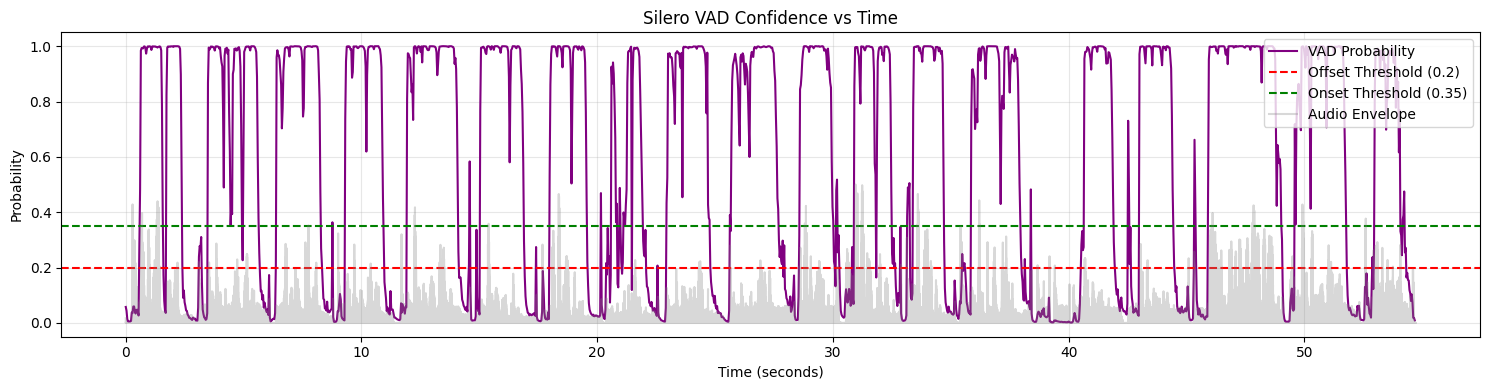

In [83]:
# @title VAD confidence plot
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort

# Let's extract the raw probabilities for the final_audio
print("Calculating VAD probabilities over time...")
vad_session = ort.InferenceSession(SILERO_MODEL_FILENAME)
sr_tensor = np.array([16000], dtype=np.int64)

chunk_size = 512
context_size = 64
state = np.zeros((2, 1, 128), dtype=np.float32)
context = np.zeros(context_size, dtype=np.float32)

probabilities = []
times = []

for i in range(0, len(final_audio), chunk_size):
    chunk = final_audio[i:i+chunk_size]
    if len(chunk) < chunk_size:
        chunk = np.pad(chunk, (0, chunk_size - len(chunk)))

    x_with_context = np.concatenate([context, chunk])
    ort_inputs = {
        "input": x_with_context.reshape(1, chunk_size + context_size).astype(np.float32),
        "state": state,
        "sr": sr_tensor
    }

    outputs = vad_session.run(None, ort_inputs)
    prob = float(outputs[0].flatten()[0])
    state = outputs[1]
    context = x_with_context[-context_size:]

    probabilities.append(prob)
    times.append(i / 16000.0)

# Plot the results
plt.figure(figsize=(15, 4))
plt.plot(times, probabilities, label="VAD Probability", color="purple")
plt.axhline(y=vad_threshold_offset, color="r", linestyle="--", label=f"Offset Threshold ({vad_threshold_offset})")
plt.axhline(y=vad_threshold_onset, color="g", linestyle="--", label=f"Onset Threshold ({vad_threshold_onset})")

# Also plot a simplified waveform behind it
time_axis = np.linspace(0, len(final_audio) / 16000.0, num=len(final_audio))
plt.plot(time_axis, np.abs(final_audio) / np.max(np.abs(final_audio)) * 0.5, color="gray", alpha=0.3, label="Audio Envelope")

plt.title("Silero VAD Confidence vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Probability")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
# @title VAD Pipeline vs. Ground Truth Comparison

def evaluate_vad_frame_based(labeled_segments, final_segments, audio_len_sec, resolution_ms=10):
    num_frames = int(np.ceil(audio_len_sec * 1000 / resolution_ms))

    gt_array = np.zeros(num_frames, dtype=bool)
    for start, end in labeled_segments:
        start_frame = int(start * 1000 / resolution_ms)
        end_frame = int(end * 1000 / resolution_ms)
        gt_array[start_frame:end_frame] = True

    det_array = np.zeros(num_frames, dtype=bool)
    for start, end in final_segments:
        start_frame = int(start * 1000 / resolution_ms)
        end_frame = int(end * 1000 / resolution_ms)
        det_array[start_frame:end_frame] = True

    tp = np.sum(gt_array & det_array)
    fp = np.sum(~gt_array & det_array)
    fn = np.sum(gt_array & ~det_array)
    tn = np.sum(~gt_array & ~det_array)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    mr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("--- Frame-based Evaluation (10ms resolution) ---")
    print(f"Precision:              {precision*100:.1f}%")
    print(f"Recall (Coverage):      {recall*100:.1f}%")
    print(f"F1-Score:               {f1*100:.1f}%")
    print(f"False Alarm Rate (FAR): {far*100:.1f}%")
    print(f"Miss Rate (MR):         {mr*100:.1f}%\n")

assert pathlib.Path(AUDIO_FILEPATH).name in GROUND_TRUTH_SEGMENTS, "Audio file not found in ground truth data"
labeled_segments = GROUND_TRUTH_SEGMENTS[pathlib.Path(AUDIO_FILEPATH).name]

if "final_segments" in locals() and "labeled_segments" in locals():
    evaluate_vad_performance(labeled_segments, final_segments)

    if "final_audio" in locals():
        audio_len_sec = len(final_audio) / 16000.0
        evaluate_vad_frame_based(labeled_segments, final_segments, audio_len_sec)

        print("Visualizing Comparison (Green = Ground Truth, Purple = Detected)...")
        visualize_comparison_with_segments(final_audio, labeled_segments, final_segments)
else:
    print("Make sure both 'final_segments' and 'labeled_segments' are defined.")

Ground Truth 0 (0.42s - 2.59s):
  -> Overlaps with Detected 0 (0.41s - 2.60s)
     Difference: Started 0.01s early, Ended 0.01s late
  Coverage: 100.0% of this segment detected.

Ground Truth 1 (3.30s - 5.79s):
  -> Overlaps with Detected 1 (3.29s - 5.86s)
     Difference: Started 0.01s early, Ended 0.08s late
  Coverage: 100.0% of this segment detected.

Ground Truth 2 (6.24s - 8.84s):
  -> Overlaps with Detected 2 (6.20s - 8.97s)
     Difference: Started 0.04s early, Ended 0.13s late
  Coverage: 100.0% of this segment detected.

Ground Truth 3 (8.86s - 11.04s):
  -> Overlaps with Detected 2 (6.20s - 8.97s)
     Difference: Started 2.66s early, Ended 2.08s early
  -> Overlaps with Detected 3 (9.11s - 11.14s)
     Difference: Started 0.25s late, Ended 0.10s late
  Coverage: 93.4% of this segment detected.

Ground Truth 4 (11.69s - 14.72s):
  -> Overlaps with Detected 4 (11.74s - 17.10s)
     Difference: Started 0.04s late, Ended 2.38s late
  Coverage: 98.5% of this segment detected.

G